# Ejercicios de aplicación: Estadística básica y descriptiva/inferencial

**Curso:** Fundamentos para Inteligencia Artificial — NRC 94103
**Semana 5:** Estadística básica y visualización de datos
**Basado en:** [`01_Estadistica_Basica.md`](01_Estadistica_Basica.md) — guía conceptual para el Portafolio de evidencias (Semana 6, `EIARV011_A6`)
**Datos:** [`StudentsPerformance.csv`](StudentsPerformance.csv) — notas de 1000 estudiantes (matemáticas, lectura y escritura), más variables de contexto (género, tipo de almuerzo, curso de preparación, nivel educativo de los padres, grupo étnico).

Este notebook desarrolla, con código Python real y ejecutado, un ejercicio práctico por cada una de las 10 secciones de `01_Estadistica_Basica.md`. La numeración de los apartados coincide con la de esa guía, para que puedas ir de la explicación conceptual al código y viceversa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('StudentsPerformance.csv')

print(f"Filas (estudiantes): {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas (estudiantes): 1000
Columnas: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 1. Tipos de variables

**Ejercicio.** Clasifica automáticamente cada columna del *dataset* como cuantitativa o cualitativa, e identifica la variable dependiente y la independiente para la pregunta: *"¿el curso de preparación influye en la nota de matemáticas?"*

In [2]:
columnas_numericas = df.select_dtypes(include='number').columns.tolist()
columnas_categoricas = df.select_dtypes(exclude='number').columns.tolist()

print("Variables cuantitativas (numéricas):")
for c in columnas_numericas:
    print(f"  - {c}")

print("\nVariables cualitativas (categóricas):")
for c in columnas_categoricas:
    print(f"  - {c}  ({df[c].nunique()} categorías: {sorted(df[c].unique())})")

print("\nPara la pregunta '¿el curso de preparación influye en la nota de matemáticas?':")
print("  Variable dependiente   -> 'math score'              (cuantitativa continua)")
print("  Variable independiente -> 'test preparation course' (cualitativa nominal, 2 categorías)")

Variables cuantitativas (numéricas):
  - math score
  - reading score
  - writing score

Variables cualitativas (categóricas):
  - gender  (2 categorías: ['female', 'male'])
  - race/ethnicity  (5 categorías: ['group A', 'group B', 'group C', 'group D', 'group E'])
  - parental level of education  (6 categorías: ["associate's degree", "bachelor's degree", 'high school', "master's degree", 'some college', 'some high school'])
  - lunch  (2 categorías: ['free/reduced', 'standard'])
  - test preparation course  (2 categorías: ['completed', 'none'])

Para la pregunta '¿el curso de preparación influye en la nota de matemáticas?':
  Variable dependiente   -> 'math score'              (cuantitativa continua)
  Variable independiente -> 'test preparation course' (cualitativa nominal, 2 categorías)


## 2. Población, muestra y tamaño de los grupos

**Ejercicio.** Calcula el tamaño total de la muestra (n) y el tamaño de cada grupo para dos variables independientes candidatas: `test preparation course` y `race/ethnicity`.

In [3]:
n_total = len(df)
print(f"Tamaño total de la muestra: n = {n_total}\n")

print("Tamaño por grupo — test preparation course:")
print(df['test preparation course'].value_counts())

print("\nTamaño por grupo — race/ethnicity:")
print(df['race/ethnicity'].value_counts().sort_index())

Tamaño total de la muestra: n = 1000

Tamaño por grupo — test preparation course:
test preparation course
none         642
completed    358
Name: count, dtype: int64

Tamaño por grupo — race/ethnicity:
race/ethnicity
group A     89
group B    190
group C    319
group D    262
group E    140
Name: count, dtype: int64


## 3. Estadística descriptiva: el "dato típico"

**Ejercicio.** Calcula la media, la mediana y la moda de las tres variables numéricas (`math score`, `reading score`, `writing score`) y compáralas en una sola tabla.

In [4]:
resumen_centro = pd.DataFrame({
    'media':   df[['math score', 'reading score', 'writing score']].mean(),
    'mediana': df[['math score', 'reading score', 'writing score']].median(),
    'moda':    df[['math score', 'reading score', 'writing score']].mode().iloc[0],
}).round(2)

resumen_centro

,media,mediana,moda
math score,66.09,66.0,65
reading score,69.17,70.0,72
writing score,68.05,69.0,74


**Interpretación:** en las tres materias, la media y la mediana están muy cerca entre sí, lo que indica distribuciones bastante simétricas, sin un grupo extremo que distorsione el promedio (ver Sección 4 para confirmarlo con la dispersión).

## 4. Estadística descriptiva: qué tan parejos son los datos

**Ejercicio.** Para `math score`, calcula el rango, la desviación estándar y los cuartiles (Q1, Q2, Q3). Luego, usando la regla del rango intercuartílico (IQR), identifica cuántos estudiantes tienen una nota de matemáticas atípica (*outlier*).

In [5]:
math = df['math score']

rango = math.max() - math.min()
desviacion = math.std(ddof=0)
q1, q2, q3 = math.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

outliers = math[(math < limite_inferior) | (math > limite_superior)]

print(f"Rango:               {rango}")
print(f"Desviación estándar: {desviacion:.2f}")
print(f"Q1 = {q1}, Q2 (mediana) = {q2}, Q3 = {q3}")
print(f"IQR = {iqr}")
print(f"Límites para outliers: [{limite_inferior:.1f}, {limite_superior:.1f}]")
print(f"Número de estudiantes con math score atípico: {len(outliers)}")
print(f"Valores atípicos encontrados: {sorted(outliers.tolist())}")

Rango:               100
Desviación estándar: 15.16
Q1 = 57.0, Q2 (mediana) = 66.0, Q3 = 77.0
IQR = 20.0
Límites para outliers: [27.0, 107.0]
Número de estudiantes con math score atípico: 8
Valores atípicos encontrados: [0, 8, 18, 19, 22, 23, 24, 26]


## 5. Qué gráfico usar para cada análisis

**Ejercicio.** Construye los tres gráficos mínimos que pide el taller: (a) un histograma de `math score` con la media y la mediana marcadas, (b) un boxplot de `math score` comparando los grupos de `test preparation course`, y (c) un diagrama de dispersión entre `reading score` y `writing score`.

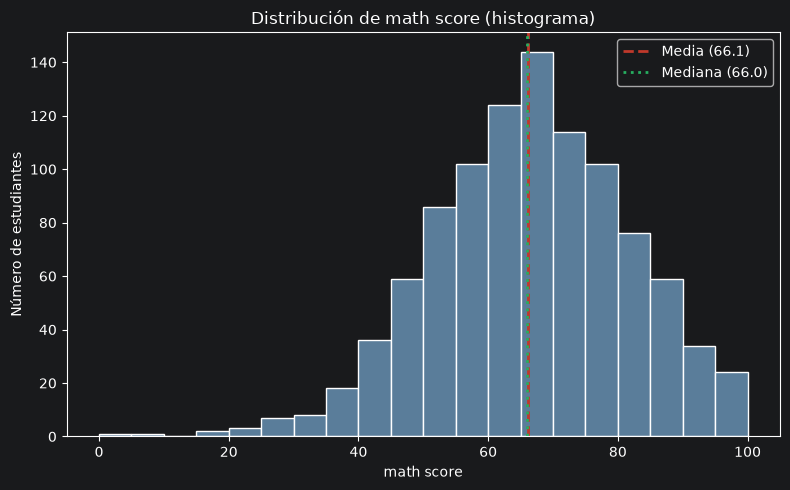

In [6]:
media = math.mean()
mediana = math.median()

plt.figure(figsize=(8, 5))
plt.hist(math, bins=20, color='#5a7d9a', edgecolor='white')
plt.axvline(media, color='#c0392b', linestyle='--', linewidth=2, label=f'Media ({media:.1f})')
plt.axvline(mediana, color='#27ae60', linestyle=':', linewidth=2, label=f'Mediana ({mediana:.1f})')
plt.title('Distribución de math score (histograma)')
plt.xlabel('math score')
plt.ylabel('Número de estudiantes')
plt.legend()
plt.tight_layout()
plt.show()

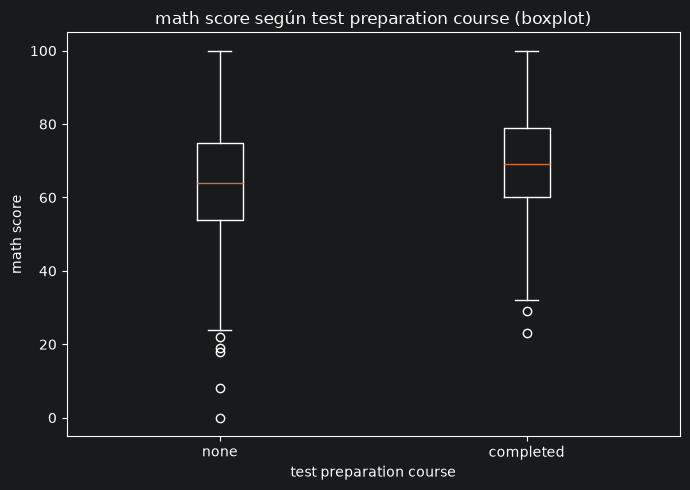

In [7]:
grupos_prep = [df.loc[df['test preparation course'] == g, 'math score']
               for g in ['none', 'completed']]

plt.figure(figsize=(7, 5))
plt.boxplot(grupos_prep, tick_labels=['none', 'completed'])
plt.title('math score según test preparation course (boxplot)')
plt.xlabel('test preparation course')
plt.ylabel('math score')
plt.tight_layout()
plt.show()

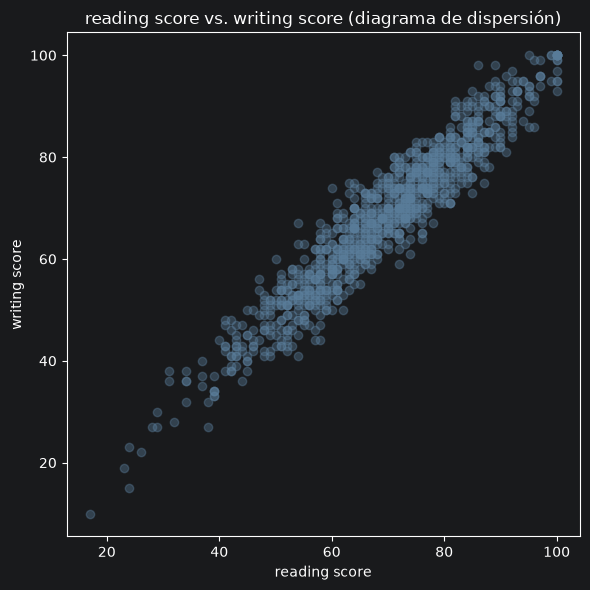

In [8]:
plt.figure(figsize=(6, 6))
plt.scatter(df['reading score'], df['writing score'], alpha=0.4, color='#5a7d9a')
plt.title('reading score vs. writing score (diagrama de dispersión)')
plt.xlabel('reading score')
plt.ylabel('writing score')
plt.tight_layout()
plt.show()

**Interpretación:** el histograma confirma la simetría de `math score` (media y mediana casi coinciden); el boxplot deja ver que el grupo `completed` tiene una caja desplazada hacia notas más altas que el grupo `none`; y la nube de puntos de lectura vs. escritura muestra una tendencia lineal creciente muy marcada, señal de una correlación fuerte (se calcula en la Sección 6).

## 6. De describir a inferir: correlación entre variables numéricas

**Ejercicio.** Calcula la matriz de correlación entre las tres variables numéricas e identifica el par de variables más fuertemente correlacionado.

In [9]:
matriz_corr = df[['math score', 'reading score', 'writing score']].corr().round(3)
matriz_corr

,math score,reading score,writing score
math score,1.000,0.818,0.803
reading score,0.818,1.000,0.955
writing score,0.803,0.955,1.000


In [10]:
corr_lectura_escritura = df['reading score'].corr(df['writing score'])
corr_mate_lectura = df['math score'].corr(df['reading score'])
corr_mate_escritura = df['math score'].corr(df['writing score'])

print(f"Correlación lectura-escritura: {corr_lectura_escritura:.3f}  (la más fuerte)")
print(f"Correlación matemáticas-lectura: {corr_mate_lectura:.3f}")
print(f"Correlación matemáticas-escritura: {corr_mate_escritura:.3f}")
print()
print("Recordatorio: una correlación alta (aquí, 0.955 entre lectura y escritura) indica una")
print("asociación estadística fuerte, pero por sí sola NO demuestra que una habilidad cause la otra.")

Correlación lectura-escritura: 0.955  (la más fuerte)
Correlación matemáticas-lectura: 0.818
Correlación matemáticas-escritura: 0.803

Recordatorio: una correlación alta (aquí, 0.955 entre lectura y escritura) indica una
asociación estadística fuerte, pero por sí sola NO demuestra que una habilidad cause la otra.


## 7. Formulación de hipótesis: H0 y H1

**Ejercicio.** Redacta formalmente H0 y H1 para la pregunta *"¿el curso de preparación influye en la nota de matemáticas?"*, y calcula el promedio de cada grupo como primer indicio antes de aplicar la prueba formal (Secciones 8-10).

In [11]:
H0 = "El promedio de 'math score' es igual entre los estudiantes que completaron el curso de preparación y los que no."
H1 = "El promedio de 'math score' es diferente entre los estudiantes que completaron el curso de preparación y los que no."

print("H0:", H0)
print("H1:", H1)
print()

promedios_por_grupo = df.groupby('test preparation course')['math score'].agg(['count', 'mean']).round(2)
print("Promedio observado por grupo (evidencia descriptiva, todavía no es una prueba formal):")
print(promedios_por_grupo)

H0: El promedio de 'math score' es igual entre los estudiantes que completaron el curso de preparación y los que no.
H1: El promedio de 'math score' es diferente entre los estudiantes que completaron el curso de preparación y los que no.

Promedio observado por grupo (evidencia descriptiva, todavía no es una prueba formal):
                         count   mean
test preparation course              
completed                  358  69.70
none                       642  64.08


## 8. Validación de supuestos: normalidad y homogeneidad de varianzas

**Ejercicio.** Evalúa si `math score` cumple el supuesto de normalidad (prueba de Shapiro-Wilk) y si los dos grupos de `test preparation course` tienen varianzas homogéneas (prueba de Levene).

In [12]:
alpha = 0.05

stat_shapiro, p_shapiro = stats.shapiro(df['math score'])
print(f"Shapiro-Wilk sobre 'math score': estadístico = {stat_shapiro:.4f}, p-value = {p_shapiro:.6f}")
if p_shapiro < alpha:
    print(f"  p < {alpha} -> hay evidencia en contra de la normalidad estricta.")
else:
    print(f"  p >= {alpha} -> no se rechaza la normalidad.")

grupo_none = df.loc[df['test preparation course'] == 'none', 'math score']
grupo_completed = df.loc[df['test preparation course'] == 'completed', 'math score']

stat_levene, p_levene = stats.levene(grupo_none, grupo_completed)
print(f"\nLevene sobre 'math score' por grupo: estadístico = {stat_levene:.4f}, p-value = {p_levene:.4f}")
if p_levene < alpha:
    print(f"  p < {alpha} -> las varianzas NO son homogéneas.")
else:
    print(f"  p >= {alpha} -> no se rechaza la homogeneidad de varianzas (los grupos tienen dispersión comparable).")

Shapiro-Wilk sobre 'math score': estadístico = 0.9932, p-value = 0.000145
  p < 0.05 -> hay evidencia en contra de la normalidad estricta.

Levene sobre 'math score' por grupo: estadístico = 0.5330, p-value = 0.4655
  p >= 0.05 -> no se rechaza la homogeneidad de varianzas (los grupos tienen dispersión comparable).


## 9. Selección y ejecución de la prueba estadística inferencial

**Ejercicio.** Con 2 grupos y varianzas homogéneas (Sección 8), aplica la prueba t de Student para muestras independientes sobre `math score` según `test preparation course`. Adicionalmente, aplica ANOVA para comparar `math score` entre los 5 grupos de `race/ethnicity`, y compárala con su alternativa no paramétrica (Kruskal-Wallis).

In [13]:
t_stat, p_t = stats.ttest_ind(grupo_none, grupo_completed, equal_var=True)
print("Prueba t de Student (2 grupos: test preparation course)")
print(f"  t = {t_stat:.3f}, p-value = {p_t:.3e}")

grupos_etnia = [g['math score'].values for _, g in df.groupby('race/ethnicity')]

f_stat, p_anova = stats.f_oneway(*grupos_etnia)
print("\nANOVA de un factor (5 grupos: race/ethnicity)")
print(f"  F = {f_stat:.3f}, p-value = {p_anova:.3e}")

h_stat, p_kruskal = stats.kruskal(*grupos_etnia)
print("\nKruskal-Wallis (alternativa no paramétrica para 5 grupos)")
print(f"  H = {h_stat:.3f}, p-value = {p_kruskal:.3e}")

correlacion_r, p_corr = stats.pearsonr(df['reading score'], df['writing score'])
print("\nCorrelación de Pearson (reading score vs. writing score)")
print(f"  r = {correlacion_r:.3f}, p-value = {p_corr:.3e}")

Prueba t de Student (2 grupos: test preparation course)
  t = -5.705, p-value = 1.536e-08

ANOVA de un factor (5 grupos: race/ethnicity)
  F = 14.594, p-value = 1.373e-11

Kruskal-Wallis (alternativa no paramétrica para 5 grupos)
  H = 57.079, p-value = 1.191e-11

Correlación de Pearson (reading score vs. writing score)
  r = 0.955, p-value = 0.000e+00


## 10. Resultados e interpretación: estadístico, p-value y decisión sobre H0

**Ejercicio.** Escribe una función que, dado un *p-value* y un nivel de significancia (alfa = 0.05), devuelva en texto la decisión sobre H0. Aplícala a los cuatro resultados de la Sección 9 y redacta la conclusión final para el portafolio.

In [14]:
def decidir_H0(p_value, alpha=0.05):
    if p_value < alpha:
        return "se RECHAZA H0 (evidencia suficiente a favor de H1)"
    else:
        return "NO se rechaza H0 (evidencia insuficiente para afirmar un efecto)"

resultados = {
    "Prueba t (test preparation course -> math score)": p_t,
    "ANOVA (race/ethnicity -> math score)": p_anova,
    "Kruskal-Wallis (race/ethnicity -> math score)": p_kruskal,
    "Correlación de Pearson (reading score vs. writing score)": p_corr,
}

for nombre, p in resultados.items():
    print(f"{nombre}")
    print(f"  p-value = {p:.3e}  ->  {decidir_H0(p)}\n")

print("Conclusión para el portafolio (ejemplo con la prueba t):")
print("Con un nivel de significancia del 5%, se rechaza la hipótesis nula: la muestra aporta")
print("evidencia de que el curso de preparación está asociado con una nota de matemáticas más")
print("alta. Esta asociación estadística no implica, por sí sola, una relación de causalidad.")

Prueba t (test preparation course -> math score)
  p-value = 1.536e-08  ->  se RECHAZA H0 (evidencia suficiente a favor de H1)

ANOVA (race/ethnicity -> math score)
  p-value = 1.373e-11  ->  se RECHAZA H0 (evidencia suficiente a favor de H1)

Kruskal-Wallis (race/ethnicity -> math score)
  p-value = 1.191e-11  ->  se RECHAZA H0 (evidencia suficiente a favor de H1)

Correlación de Pearson (reading score vs. writing score)
  p-value = 0.000e+00  ->  se RECHAZA H0 (evidencia suficiente a favor de H1)

Conclusión para el portafolio (ejemplo con la prueba t):
Con un nivel de significancia del 5%, se rechaza la hipótesis nula: la muestra aporta
evidencia de que el curso de preparación está asociado con una nota de matemáticas más
alta. Esta asociación estadística no implica, por sí sola, una relación de causalidad.


---

### Cierre

Cada sección de este notebook reproduce, con código real, el mismo recorrido conceptual de `01_Estadistica_Basica.md`: clasificar variables, describir la muestra, resumir con medidas de tendencia central y dispersión, visualizar, plantear hipótesis, validar supuestos, elegir la prueba correcta y, finalmente, interpretar el resultado en función de H0. Este mismo flujo es el que debes reproducir con el *dataset* que elijas para el Portafolio de evidencias (`EIARV011_A6`, Semana 6).